In [ ]:
!pip install mlflow

In [ ]:
import mlflow

mlflow.set_experiment("Evaluate Models - Income")
with mlflow.start_run(run_name="Evaluate Models - Income"):
    # Seu código para avaliar modelos de renda
    mlflow.log_param("evaluation_type", "model_comparison")
    mlflow.log_artifact("../results/evaluation/income", artifact_path="income_model_evaluation")
    mlflow.log_param("input", "Model checkpoints and logs from ../models/income_separate/ and ../models/income_combined/")
    mlflow.log_param("output", "Files containing evaluation results: ../results/evaluation/income/")
    mlflow.set_tag("aws_instance_type", "2vCPU + 8 GiB")

**DHS in-country cross-validated model results.**

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Imports-and-Constants" data-toc-modified-id="Imports-and-Constants-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Imports and Constants</a></span></li><li><span><a href="#Load-Saved-Data" data-toc-modified-id="Load-Saved-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load Saved Data</a></span><ul class="toc-item"><li><span><a href="#Load-labels,-locs,-and-years" data-toc-modified-id="Load-labels,-locs,-and-years-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Load <code>labels</code>, <code>locs</code>, and <code>years</code></a></span></li><li><span><a href="#Load-loc_dict" data-toc-modified-id="Load-loc_dict-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Load <code>loc_dict</code></a></span></li><li><span><a href="#Get-urban-v.-rural-indices" data-toc-modified-id="Get-urban-v.-rural-indices-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Get urban v. rural indices</a></span></li><li><span><a href="#country_indices-and-country_labels" data-toc-modified-id="country_indices-and-country_labels-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span><code>country_indices</code> and <code>country_labels</code></a></span></li></ul></li><li><span><a href="#Load-saved-preds" data-toc-modified-id="Load-saved-preds-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Load saved preds</a></span><ul class="toc-item"><li><span><a href="#Create-CSV-of-all-preds" data-toc-modified-id="Create-CSV-of-all-preds-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Create CSV of all preds</a></span></li></ul></li><li><span><a href="#Overall-MSE,-$R^2$,-$r^2$,-rank-corr" data-toc-modified-id="Overall-MSE,-$R^2$,-$r^2$,-rank-corr-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Overall MSE, $R^2$, $r^2$, rank-corr</a></span><ul class="toc-item"><li><span><a href="#Individual-model-results" data-toc-modified-id="Individual-model-results-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Individual model results</a></span></li><li><span><a href="#Model-Similarity-Heatmaps" data-toc-modified-id="Model-Similarity-Heatmaps-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Model Similarity Heatmaps</a></span></li><li><span><a href="#Cumulative-analysis" data-toc-modified-id="Cumulative-analysis-4.3"><span class="toc-item-num">4.3&nbsp;&nbsp;</span>Cumulative analysis</a></span></li></ul></li><li><span><a href="#Break-down-by-country,-urban/rural" data-toc-modified-id="Break-down-by-country,-urban/rural-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Break-down by country, urban/rural</a></span></li><li><span><a href="#$r^2$-over-all-countries" data-toc-modified-id="$r^2$-over-all-countries-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>$r^2$ over all countries</a></span></li><li><span><a href="#Break-down-by-country-year,-urban/rural" data-toc-modified-id="Break-down-by-country-year,-urban/rural-7"><span class="toc-item-num">7&nbsp;&nbsp;</span>Break-down by country-year, urban/rural</a></span></li><li><span><a href="#Urban/rural" data-toc-modified-id="Urban/rural-8"><span class="toc-item-num">8&nbsp;&nbsp;</span>Urban/rural</a></span><ul class="toc-item"><li><span><a href="#By-Country" data-toc-modified-id="By-Country-8.1"><span class="toc-item-num">8.1&nbsp;&nbsp;</span>By Country</a></span></li></ul></li><li><span><a href="#Model-performance-as-function-of-NL" data-toc-modified-id="Model-performance-as-function-of-NL-9"><span class="toc-item-num">9&nbsp;&nbsp;</span>Model performance as function of NL</a></span><ul class="toc-item"><li><span><a href="#When-NL-=-0" data-toc-modified-id="When-NL-=-0-9.1"><span class="toc-item-num">9.1&nbsp;&nbsp;</span>When NL = 0</a></span></li><li><span><a href="#Predictions-vs.-NL-mean" data-toc-modified-id="Predictions-vs.-NL-mean-9.2"><span class="toc-item-num">9.2&nbsp;&nbsp;</span>Predictions vs. NL mean</a></span></li></ul></li></ul></div>

# Imports and Constants

Installing Libraries

In [1]:
!pip install matplotlib
!pip install seaborn
!pip install pandas==0.25.3


[notice] A new release of pip available: 22.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip available: 22.3.1 -> 23.3.2
[notice] To update, run: pip install --upgrade pip
  Using cached pandas-0.25.3.tar.gz (12.6 MB)
  Preparing metadata (setup.py) ... done
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [2172 lines of output]
      /tmp/pip-install-1su0g2oz/pandas_eb45b830a3cb4969beda4b96f0f035e5/setup.py:54: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
        _CYTHON_INSTALLED = ver >= LooseVersion(min_cython_ver)
      running bdist_wheel
      running build
      running build_py
      creating build
      creating build/lib.linux-x86_64-cpython-39
      creating build/lib.linux-x86_64-cpython-39/pandas
      copying pandas/__init__.py -> build/lib.linux-x86_64-cpython-39/pandas
      copying pandas/_typing.py ->

Importing libraries

In [3]:
from collections import defaultdict
import itertools
import pickle
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


from batchers import dataset_constants
from utils.analysis import (
    calc_score,
    chunk_vs_score,
    evaluate_df,
    plot_chunk_vs_score,
    plot_label_vs_score,
    plot_percdata_vs_score,
    sorted_scores)
from utils.general import colordisplay, load_npz
from utils.plot import scatter_preds, symmetric_heatmap

In [4]:
print(pd.__version__)

1.5.2


All the models Already trained with the directories to its basefiles

In [5]:
label = "income"
LOGS_ROOT_DIR = f'/root/reproducible/logs/{label}/'
DATASET_NAME = 'DHS_OOC_A'
base_path = f"/root/reproducible/logs/{label}"
MODEL_NAME_TO_DIR = {
    
    # KNN Only Models
           'KNN NL mean scalar': base_path + '/dhs_knn/incountry_nlmean_scalar',
           'KNN NL center scalar': base_path + '/dhs_knn/incountry_nlcenter_scalar',
           'KNN NL hist': base_path +  '/dhs_knn/incountry_nl_hist',
    
    # Ridge Models
           'Ridge NL mean scalar': base_path + '/dhs_ridge/incountry_nlmean_scalar',
           'Ridge NL center scalar': base_path + '/dhs_ridge/incountry_nlcenter_scalar',
           'Ridge RGB hist':  base_path + '/dhs_ridge/incountry_rgb_hist',
           'Ridge MS hist': base_path + '/dhs_ridge/incountry_ms_hist',
           'Ridge NL hist': base_path + '/dhs_ridge/incountry_nl_hist',
           'Ridge RGB+NL hist': base_path + '/dhs_ridge/incountry_rgbnl_hist',
           'Ridge MS+NL hist': base_path + '/dhs_ridge/incountry_msnl_hist',

     # ResNet with Ridge Models
           'Resnet-18 MS - E': base_path + '/resnet_ms',
           'Resnet-18 MS - ADE':base_path + '/resnet_ms/3_folds',
           'Resnet-18 MS - All':base_path + '/resnet_ms/All_folds',
           'Resnet-18 NL': base_path + '/resnet_nl',
           #'Resnet-18 MS_250': base_path + '/resnet_ms_250',
           'Resnet-18 MS+NL concat': base_path + '/resnet_msnl_concat',
           #'Resnet-18 MS_250+NL concat': base_path + '/resnet_msnl_concat_250',
}

MODEL_NAMES = sorted(MODEL_NAME_TO_DIR.keys())

# Load Saved Data

## Load `labels`, `locs`, and `years`

In [6]:
countries=["brazil"]

print(f'for label {label}:')
print(f'dhs_co_{label}.npz Dictionary Key, Value Type and Shape')
npz = load_npz(f'/root/reproducible/Datasets/SelectedClusters/dhs_co_{label}.npz')

labels = npz['labels']
locs = npz['locs']
years = npz['years']
nls_center = npz['nls_center']
nls_mean = npz['nls_mean']

num_examples = len(labels)
assert np.all(np.asarray([len(labels), len(locs), len(years), len(nls_center), len(nls_mean)]) == num_examples)
print(labels)

for label income:
dhs_co_income.npz Dictionary Key, Value Type and Shape
image_hists: dtype=int64, shape=(30000, 8, 102)
labels: dtype=float32, shape=(30000,)
locs: dtype=float32, shape=(30000, 2)
years: dtype=int32, shape=(30000,)
nls_center: dtype=float32, shape=(30000,)
nls_mean: dtype=float32, shape=(30000,)
[0.36177003 0.5788512  0.5504683  ... 0.5828212  0.29100174 0.5901569 ]


## Load `loc_dict`

`loc_dict` has the format:
```python
{
    (lat, lon): {
        'cluster': 1,
        'country': 'malawi',
        'country_year': 'malawi_2012',  # surveyID
        'households': 25,
        'urban': False,
        'wealth': -0.513607621192932,
        'wealthpooled': -0.732255101203918,
        'year': 2012
    }, ...
}
```

NOTE: `year` and `country_year` might differ in the year. `country_year` is the survey ID, which says which year the survey started. However, sometimes the DHS surveys cross the year-boundary, in which case `country_year` will remain the same but `year` will be the next year.

In [7]:
loc_dict_path = f'/root/reproducible/Datasets/SelectedClusters/loc_dict_brazil_2010_{label}.pkl'
with open(loc_dict_path, 'rb') as f:
    loc_dict = pickle.load(f)

## Get urban v. rural indices

In [8]:
def get_urban_rural_indices(locs, loc_dict):
    '''
    Args
    - locs: np.array, shape [N, 2]
    - loc_dict: dict, (lat, lon) => dict

    Returns
    - urban_indices: np.array, shape [num_urban]
    - rural_indices: np.array, shape [num_rural]
    '''
    urban_indices = []
    rural_indices = []

    for i, loc in enumerate(locs):
        loc = tuple(loc)
        if loc_dict[loc]['urban'] == 'RURAL':
            rural_indices.append(i)
        else:
            urban_indices.append(i)
    urban_indices = np.asarray(urban_indices)
    rural_indices = np.asarray(rural_indices)
    print(f'num urban: {len(urban_indices)}\t num rural: {len(rural_indices)}')
    return urban_indices, rural_indices

urban_indices, rural_indices = get_urban_rural_indices(locs, loc_dict)

KeyError: 'urban'

In [9]:
urban_indices = []
rural_indices = np.arange(num_examples)

Figure - Cluster Distribution Split by Cluster Type
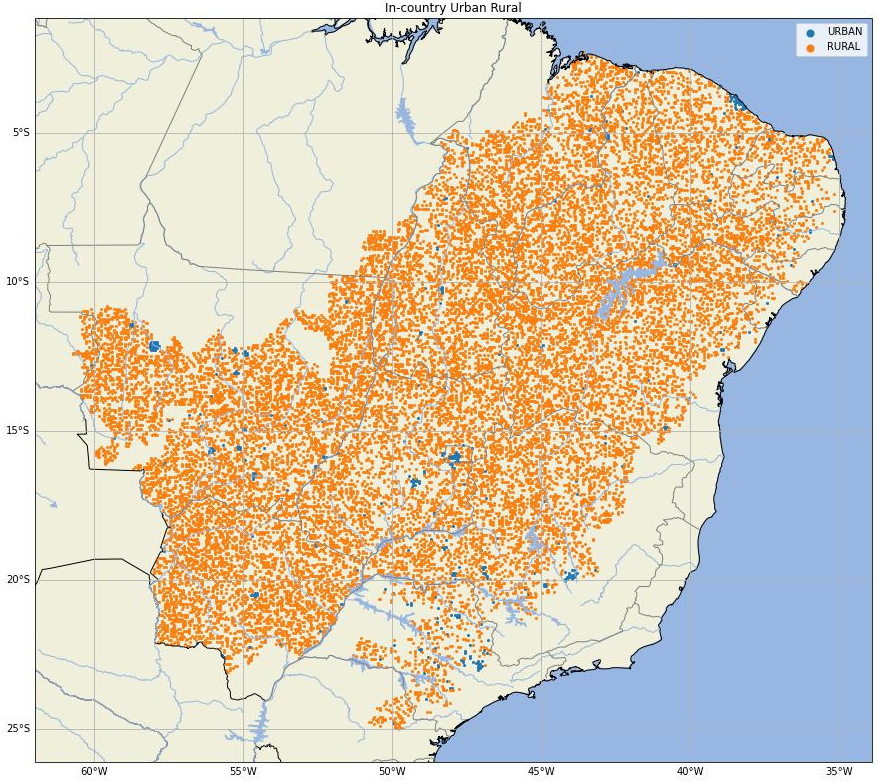

## `country_indices` and `country_labels`

`country_indices` is a dictionary that maps a country name to a sorted `np.array` of its indices
```python
{ 'malawi': np.array([ 8530,  8531,  8532, ..., 10484, 10485, 10486]), ... }
```

`country_labels` is a `np.array` that shows which country each example belongs to
```python
np.array([0, 0, 0, 0, ..., 22, 22, 22])
```
where countries are indexed by their position in `dataset_constants.DHS_COUNTRIES`

In [10]:
country_indices = defaultdict(list)  # country => np.array of indices
country_labels = np.zeros(num_examples, dtype=np.int32)  # np.array of country labels

for i, loc in enumerate(locs):
    country = loc_dict[tuple(loc)]['country']
    country_indices[country].append(i)

for i, country in enumerate(countries):
    country_indices[country] = np.asarray(country_indices[country])
    print(country_indices[country])
    indices = country_indices[country]
    country_labels[indices] = i

country_indices['overall'] = np.arange(num_examples)

[    0     1     2 ... 29997 29998 29999]


# Load saved preds

In [11]:
preds = {}

for model_name, model_dir in MODEL_NAME_TO_DIR.items():
    print(model_name)
    npz_path = os.path.join(LOGS_ROOT_DIR, model_dir, 'test_preds.npz')
    preds[model_name] = load_npz(npz_path)['test_preds']

KNN NL mean scalar
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
KNN NL center scalar
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
KNN NL hist
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge NL mean scalar
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge NL center scalar
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge RGB hist
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge MS hist
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge NL hist
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge RGB+NL hist
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Ridge MS+NL hist
labels: dtype=float32, shape=(30000,)
test_preds: dtype=float32, shape=(30000,)
Resnet-18 MS - E
labels: d

## Create CSV of all preds

In [12]:
preds_df = pd.DataFrame(
    columns=['lat', 'lon', 'country', 'year', 'urban', 'label'] + MODEL_NAMES)
preds_df['lat'] = locs[:, 0]
preds_df['lon'] = locs[:, 1]
preds_df['label'] = labels
preds_df['year'] = years
preds_df['country'] = np.asarray(countries)[country_labels]
preds_df.loc[:, 'urban'] = False
preds_df.loc[urban_indices, 'urban'] = True

print("All Models Analyzed:")
for model_name in MODEL_NAMES:
    print(model_name)
    preds_df[model_name] = preds[model_name]

preds_df.to_csv(LOGS_ROOT_DIR + 'dhs_incountry_predsnew.csv', index=False)


/tmp/ipykernel_1305/2635021699.py:8: FutureWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  preds_df.loc[:, 'urban'] = False


All Models Analyzed:
KNN NL center scalar
KNN NL hist
KNN NL mean scalar
Resnet-18 MS - ADE
Resnet-18 MS - All
Resnet-18 MS - E
Resnet-18 MS+NL concat
Resnet-18 NL
Ridge MS hist
Ridge MS+NL hist
Ridge NL center scalar
Ridge NL hist
Ridge NL mean scalar
Ridge RGB hist
Ridge RGB+NL hist


In [13]:
with pd.option_context('display.max_rows', 20):
    display(preds_df)

preds_df.to_csv(LOGS_ROOT_DIR + 'alldata.csv')


,lat,lon,country,year,urban,label,KNN NL center scalar,KNN NL hist,KNN NL mean scalar,Resnet-18 MS - ADE,...,Resnet-18 MS - E,Resnet-18 MS+NL concat,Resnet-18 NL,Ridge MS hist,Ridge MS+NL hist,Ridge NL center scalar,Ridge NL hist,Ridge NL mean scalar,Ridge RGB hist,Ridge RGB+NL hist
0,-3.002288,-40.135723,brazil,2010,False,0.361770,0.463345,0.440395,0.455466,0.373943,...,0.409909,0.363078,0.460871,0.442005,0.439956,0.487704,0.452916,0.488358,0.461022,0.450829
1,-15.044956,-50.668472,brazil,2010,False,0.578851,0.493323,0.472351,0.448621,0.625349,...,0.625018,0.624341,0.490947,0.626985,0.612411,0.488287,0.484713,0.488287,0.654321,0.650688
2,-15.484209,-50.608284,brazil,2010,False,0.550468,0.481997,0.500068,0.497150,0.562196,...,0.534220,0.561567,0.492687,0.526815,0.527210,0.488562,0.491175,0.488562,0.500796,0.501845
3,-12.923420,-55.302879,brazil,2010,False,0.559279,0.483650,0.491089,0.490476,0.564173,...,0.563702,0.565062,0.488142,0.534544,0.535170,0.488142,0.490816,0.488142,0.550990,0.553247
4,-17.504314,-48.080425,brazil,2010,False,0.610901,0.493323,0.487807,0.493598,0.611610,...,0.610713,0.610379,0.492039,0.595611,0.586711,0.488287,0.490758,0.488287,0.535976,0.537252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,-14.481491,-56.747372,brazil,2010,False,0.515834,0.493323,0.452586,0.478885,0.617603,...,0.599730,0.618420,0.484337,0.566572,0.564918,0.488287,0.488580,0.488287,0.572921,0.572699
29996,-3.002288,-43.506203,brazil,2010,False,0.270639,0.481997,0.500068,0.497150,0.365558,...,0.271840,0.362665,0.490118,0.410294,0.410602,0.488562,0.491175,0.488562,0.387093,0.390420
29997,-12.550933,-51.029594,brazil,2010,False,0.582821,0.485027,0.495172,0.495172,0.570349,...,0.561254,0.485099,0.489969,0.468844,0.468883,0.488753,0.491237,0.488699,0.465736,0.466448
29998,-9.036055,-40.797783,brazil,2010,False,0.291002,0.485027,0.495172,0.495172,0.379087,...,0.382573,0.396224,0.489969,0.331057,0.331236,0.488753,0.491237,0.488699,0.367744,0.371580


# Overall MSE, $R^2$, $r^2$, rank-corr

## Individual model results

In [14]:
overall_df = evaluate_df(preds_df, cols=MODEL_NAMES)
overall_df.sort_values(by='r2', ascending=False, inplace=True)
display(overall_df)
overall_df.to_csv(LOGS_ROOT_DIR + 'performance.csv')

,r2,R2,mse,rank
Resnet-18 MS - E,0.744299,0.744200,0.003986,0.860588
Resnet-18 MS - ADE,0.654568,0.654360,0.005385,0.813142
Resnet-18 MS+NL concat,0.606712,0.606589,0.006130,0.786551
Resnet-18 MS - All,0.606167,0.606041,0.006138,0.786005
Ridge MS hist,0.480806,0.480734,0.008091,0.720769
Ridge MS+NL hist,0.480439,0.480409,0.008096,0.720452
Ridge RGB+NL hist,0.313689,0.313677,0.010693,0.591799
Ridge RGB hist,0.310767,0.310743,0.010739,0.588576
KNN NL hist,0.016005,0.015770,0.015335,0.077713
Ridge NL hist,0.013271,0.013259,0.015374,0.079519


Plot Ridge Evaluations 

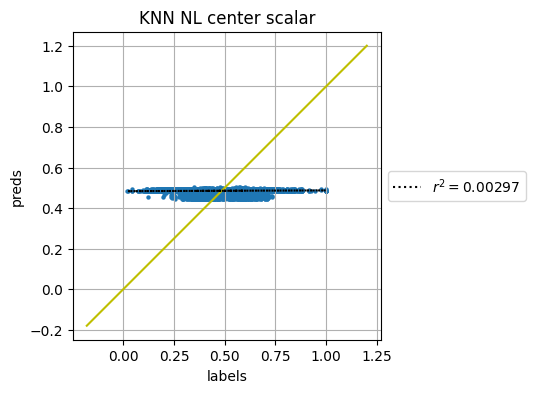

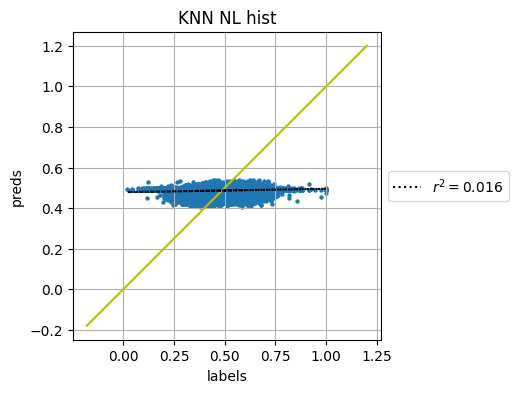

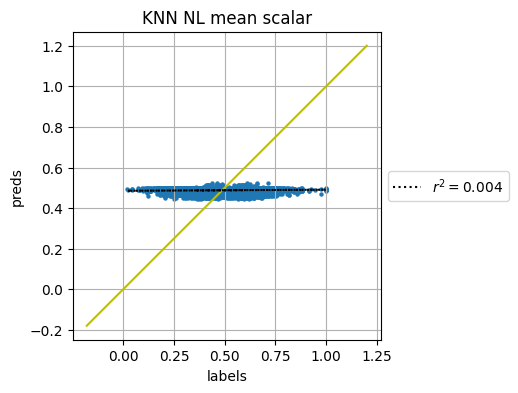

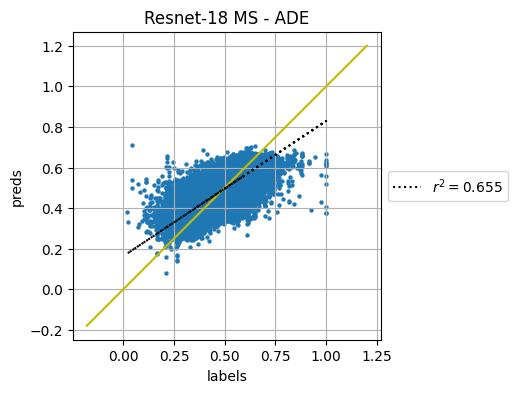

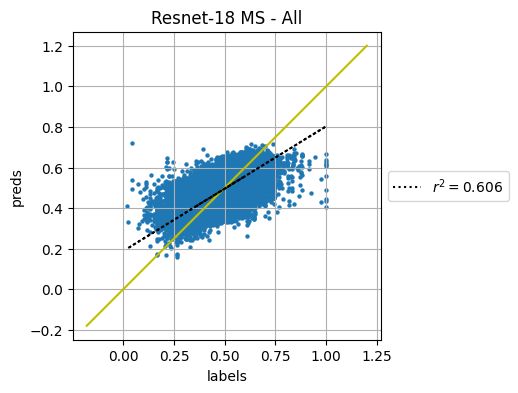

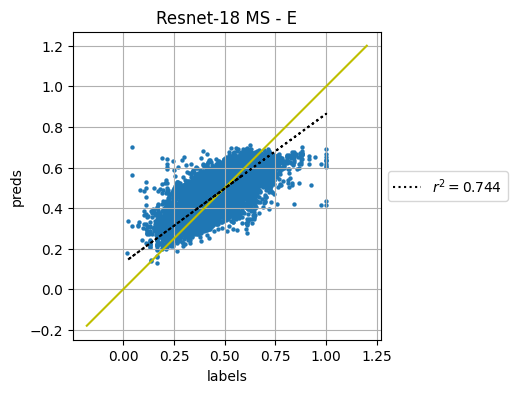

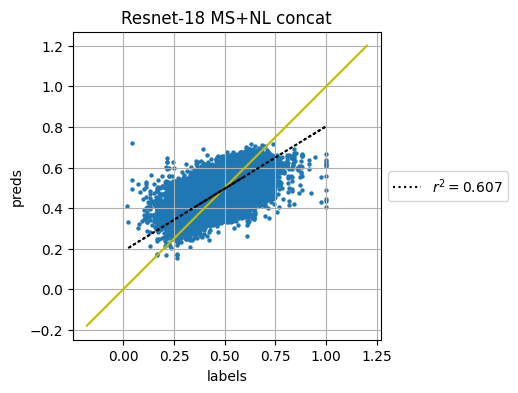

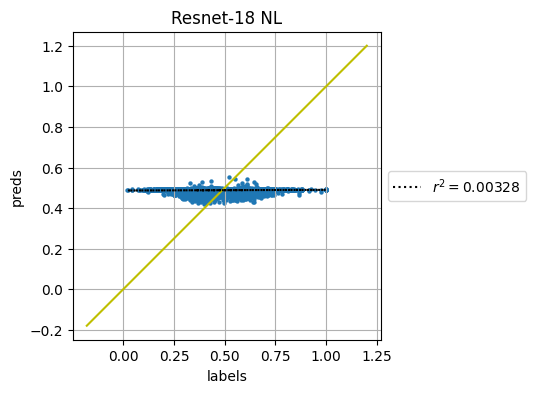

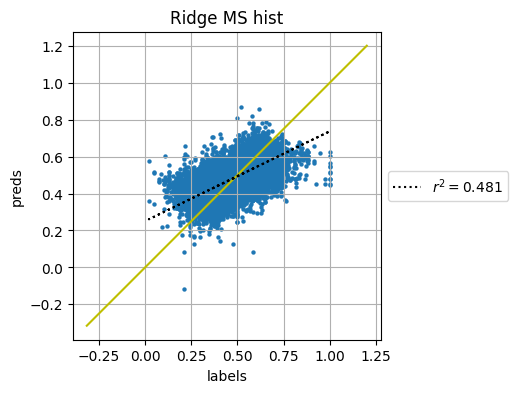

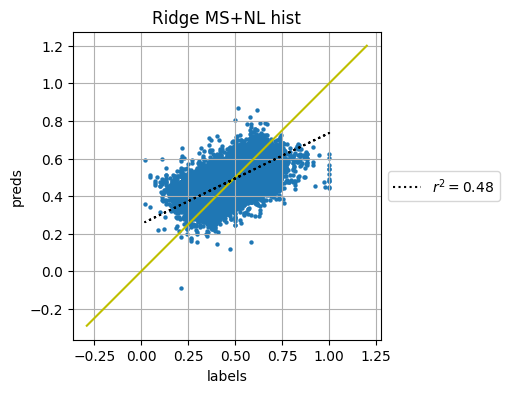

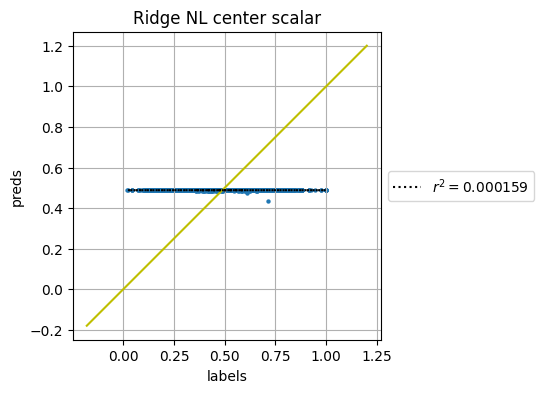

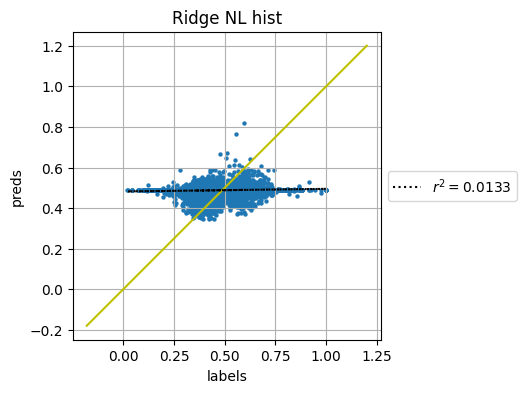

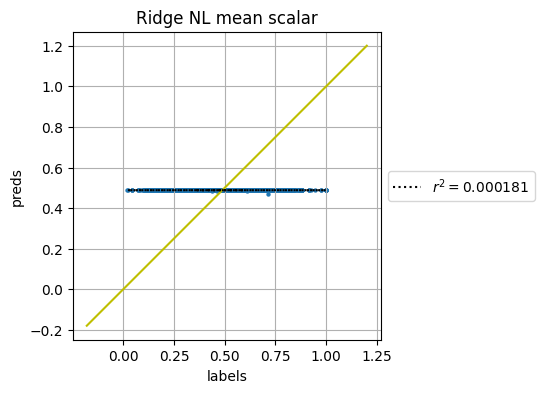

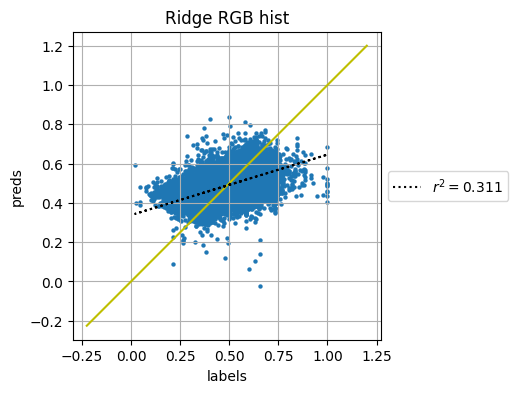

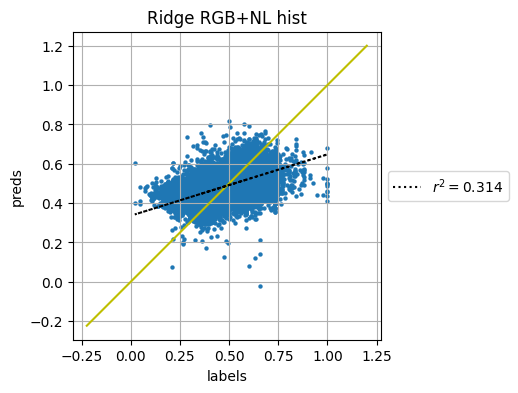

In [15]:
for model_name in MODEL_NAMES:
    model_preds = preds[model_name]
    scatter_preds(
        labels=labels,
        preds=model_preds,
        title=model_name,
        figsize=(4, 4))

# Stopped running the code at this point

## Model Similarity Heatmaps

In [16]:
model_names_by_mse = overall_df.sort_values(by='mse').index
print(model_names_by_mse)
num_models = len(preds)

r2_mat = np.eye(num_models, dtype=np.float64)
rank_mat = np.eye(num_models, dtype=np.float64)

for i, j in itertools.combinations(range(num_models), r=2):
    model_name1 = model_names_by_mse[i]
    model_name2 = model_names_by_mse[j]

    m1_preds = preds[model_name1]
    m2_preds = preds[model_name2]

    r2_mat[i, j] = calc_score(m1_preds, m2_preds, metric='r2')
    rank_mat[i, j] = calc_score(m1_preds, m2_preds, metric='rank')
    r2_mat[j, i] = r2_mat[i, j]
    rank_mat[j, i] = rank_mat[i, j]

Index(['Resnet-18 MS - E', 'Resnet-18 MS - ADE', 'Resnet-18 MS+NL concat',
       'Resnet-18 MS - All', 'Ridge MS hist', 'Ridge MS+NL hist',
       'Ridge RGB+NL hist', 'Ridge RGB hist', 'KNN NL hist', 'Ridge NL hist',
       'KNN NL mean scalar', 'Resnet-18 NL', 'KNN NL center scalar',
       'Ridge NL mean scalar', 'Ridge NL center scalar'],
      dtype='object')


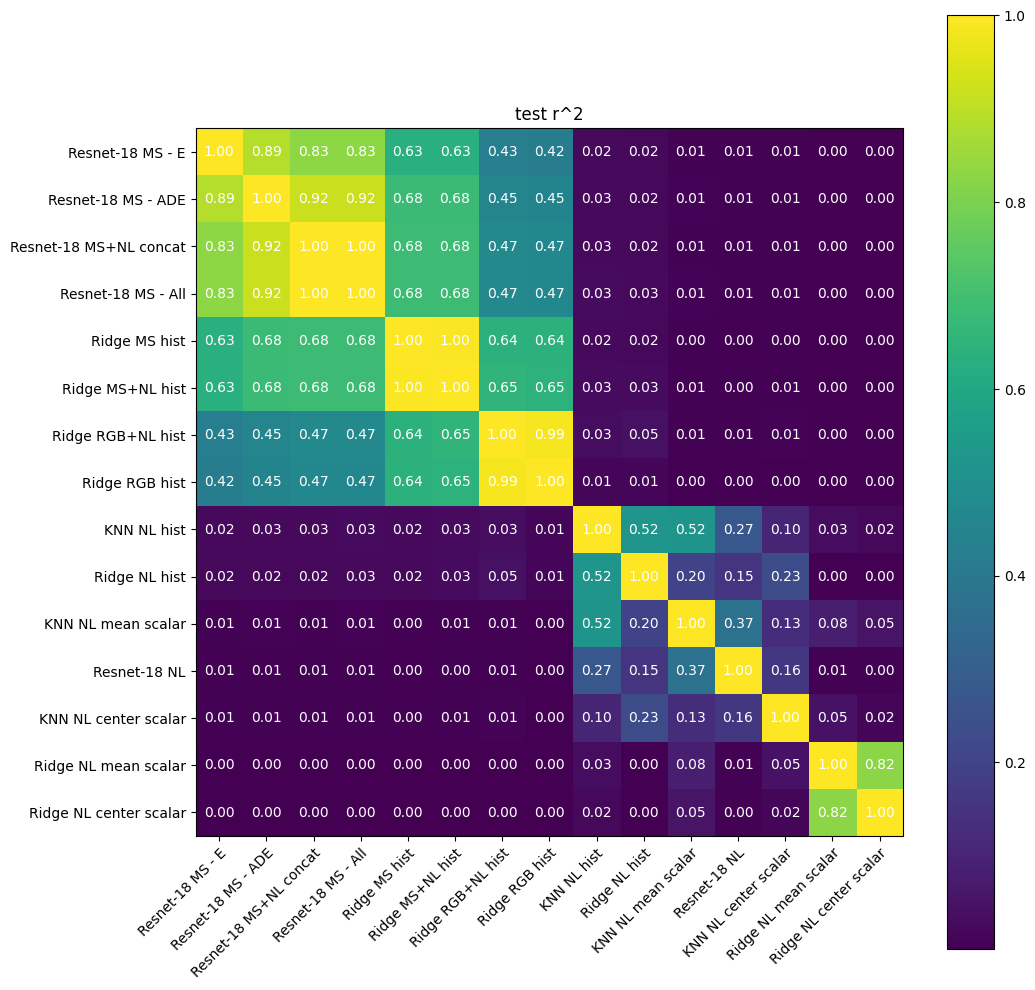

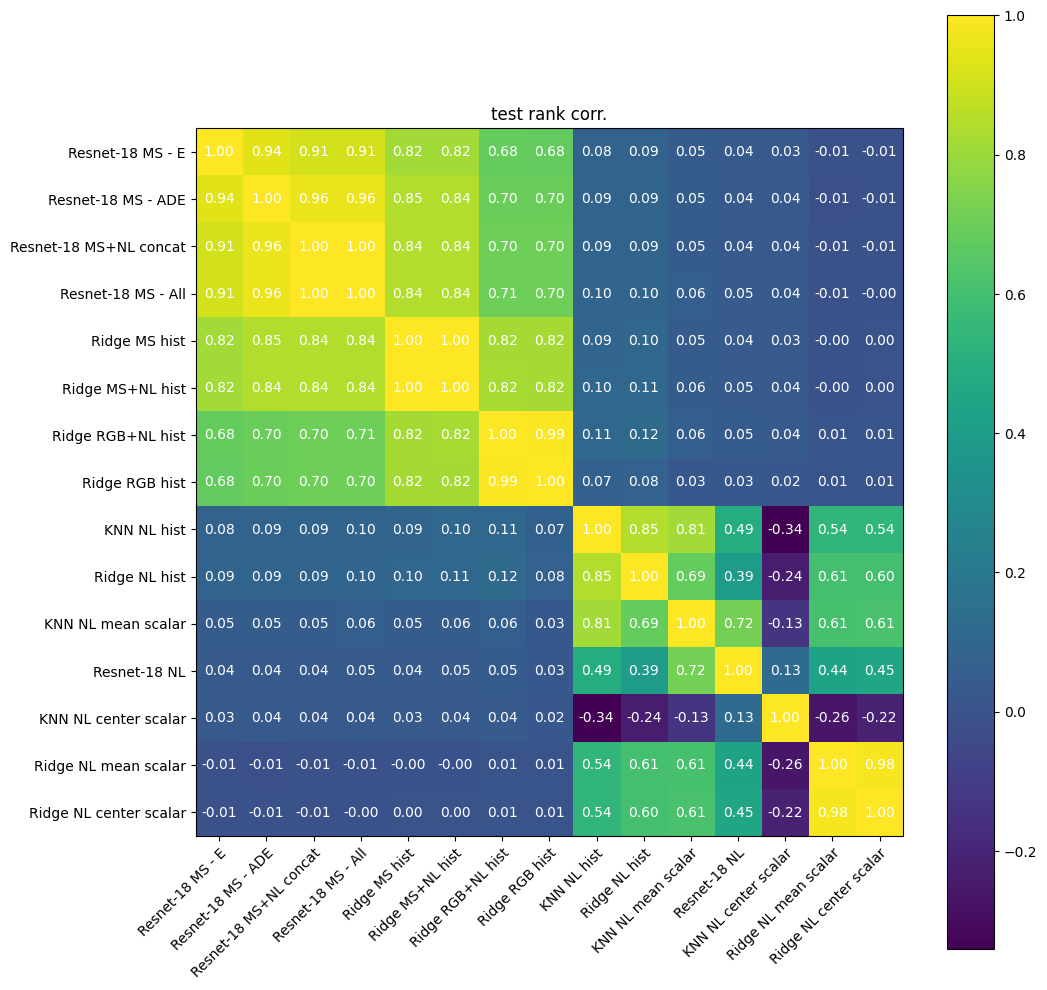

In [17]:
symmetric_heatmap(r2_mat, labels=model_names_by_mse, format_spec='{:.2f}', title='test r^2')
symmetric_heatmap(rank_mat, labels=model_names_by_mse, format_spec='{:.2f}', title='test rank corr.')

## Cumulative analysis

In [18]:
ridge_model_indices, ridge_model_names = [], []
resnet_model_indices, resnet_model_names = [], []

for i, model_name in enumerate(model_names_by_mse):
    if 'Resnet' not in model_name:
        ridge_model_indices.append(i)
        ridge_model_names.append(model_name)
    elif 'Resnet' in model_name:
        resnet_model_indices.append(i)
        resnet_model_names.append(model_name)

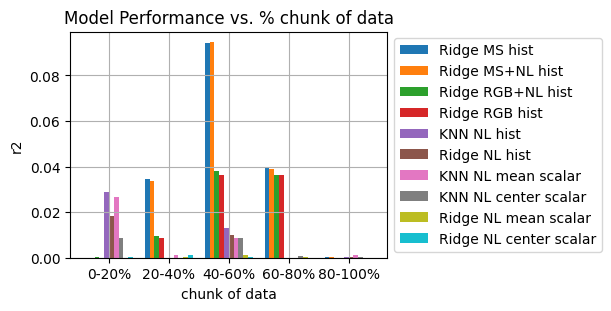

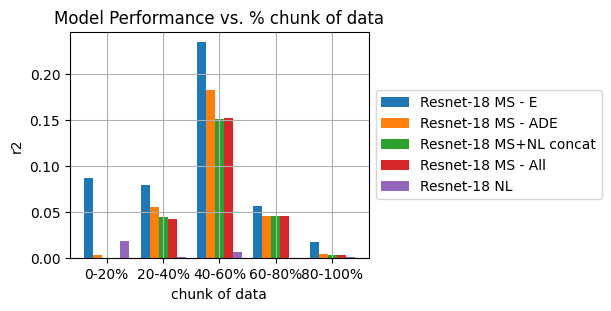

In [19]:
chunk_r2s = np.zeros([len(model_names_by_mse), 5])
for i, model_name in enumerate(model_names_by_mse):
    chunk_r2s[i, :] = chunk_vs_score(preds=preds[model_name], labels=labels, nchunks=5, metric='r2')

plot_chunk_vs_score(scores=chunk_r2s[ridge_model_indices], figsize=(6, 3),
                    legends=ridge_model_names, metric='r2')

plot_chunk_vs_score(scores=chunk_r2s[resnet_model_indices], figsize=(6, 3),
                    legends=resnet_model_names, metric='r2')

# Break-down by country, urban/rural

Tables with model Evaluation split for Urban/Rural Clusters

In [20]:
country_df = (
    preds_df
    .groupby('country')
    .apply(evaluate_df, cols=MODEL_NAMES, index_name='model'))

country_urban_df = (
    preds_df
    .groupby(['country', 'urban'])
    .apply(evaluate_df, cols=MODEL_NAMES, index_name='model'))

country_df.sort_values(by='r2', ascending=False, inplace=True)

with pd.option_context('display.precision', 3):
    display(country_df)
    display(country_urban_df)
    
    
country_df.to_csv('/root/reproducible/logs/income/country.csv')

country_urban_df.to_csv('/root/reproducible/logs/income/country_urban.csv')


r2         R2    mse   rank
country model                                                     
brazil  Resnet-18 MS - E        7.443e-01  7.442e-01  0.004  0.861
        Resnet-18 MS - ADE      6.546e-01  6.544e-01  0.005  0.813
        Resnet-18 MS+NL concat  6.067e-01  6.066e-01  0.006  0.787
        Resnet-18 MS - All      6.062e-01  6.060e-01  0.006  0.786
        Ridge MS hist           4.808e-01  4.807e-01  0.008  0.721
        Ridge MS+NL hist        4.804e-01  4.804e-01  0.008  0.720
        Ridge RGB+NL hist       3.137e-01  3.137e-01  0.011  0.592
        Ridge RGB hist          3.108e-01  3.107e-01  0.011  0.589
        KNN NL hist             1.601e-02  1.577e-02  0.015  0.078
        Ridge NL hist           1.327e-02  1.326e-02  0.015  0.080
        KNN NL mean scalar      4.000e-03  3.586e-03  0.016  0.048
        Resnet-18 NL            3.281e-03  3.270e-03  0.016  0.040
        KNN NL center scalar    2.966e-03  2.219e-03  0.016  0.028
        Ridge NL mean scalar    1.814e-04 -9.723e-05  0.016 -0.008
        Ridge NL center scalar  1.591e-04 -1.229e-04  0.016 -0.006

r2         R2    mse   rank
country urban model                                                     
brazil  False KNN NL center scalar    2.966e-03  2.219e-03  0.016  0.028
              KNN NL hist             1.601e-02  1.577e-02  0.015  0.078
              KNN NL mean scalar      4.000e-03  3.586e-03  0.016  0.048
              Resnet-18 MS - ADE      6.546e-01  6.544e-01  0.005  0.813
              Resnet-18 MS - All      6.062e-01  6.060e-01  0.006  0.786
              Resnet-18 MS - E        7.443e-01  7.442e-01  0.004  0.861
              Resnet-18 MS+NL concat  6.067e-01  6.066e-01  0.006  0.787
              Resnet-18 NL            3.281e-03  3.270e-03  0.016  0.040
              Ridge MS hist           4.808e-01  4.807e-01  0.008  0.721
              Ridge MS+NL hist        4.804e-01  4.804e-01  0.008  0.720
              Ridge NL center scalar  1.591e-04 -1.229e-04  0.016 -0.006
              Ridge NL hist           1.327e-02  1.326e-02  0.015  0.080
              Ridge NL mean scalar    1.814e-04 -9.723e-05  0.016 -0.008
              Ridge RGB hist          3.108e-01  3.107e-01  0.011  0.589
              Ridge RGB+NL hist       3.137e-01  3.137e-01  0.011  0.592

# Break-down by country-year, urban/rural

In [21]:
countryyear_df = (
    preds_df
    .groupby(['country', 'year'])
    .apply(evaluate_df, cols=MODEL_NAMES, index_name='model'))
countryyear_urban_df = (
    preds_df
    .groupby(['country', 'year', 'urban'])
    .apply(evaluate_df, cols=MODEL_NAMES, index_name='model'))

with pd.option_context('display.precision', 3):
    display(countryyear_df)
    display(countryyear_urban_df)

r2         R2    mse   rank
country year model                                                     
brazil  2010 KNN NL center scalar    2.966e-03  2.219e-03  0.016  0.028
             KNN NL hist             1.601e-02  1.577e-02  0.015  0.078
             KNN NL mean scalar      4.000e-03  3.586e-03  0.016  0.048
             Resnet-18 MS - ADE      6.546e-01  6.544e-01  0.005  0.813
             Resnet-18 MS - All      6.062e-01  6.060e-01  0.006  0.786
             Resnet-18 MS - E        7.443e-01  7.442e-01  0.004  0.861
             Resnet-18 MS+NL concat  6.067e-01  6.066e-01  0.006  0.787
             Resnet-18 NL            3.281e-03  3.270e-03  0.016  0.040
             Ridge MS hist           4.808e-01  4.807e-01  0.008  0.721
             Ridge MS+NL hist        4.804e-01  4.804e-01  0.008  0.720
             Ridge NL center scalar  1.591e-04 -1.229e-04  0.016 -0.006
             Ridge NL hist           1.327e-02  1.326e-02  0.015  0.080
             Ridge NL mean scalar    1.814e-04 -9.723e-05  0.016 -0.008
             Ridge RGB hist          3.108e-01  3.107e-01  0.011  0.589
             Ridge RGB+NL hist       3.137e-01  3.137e-01  0.011  0.592

r2         R2    mse   rank
country year urban model                                                     
brazil  2010 False KNN NL center scalar    2.966e-03  2.219e-03  0.016  0.028
                   KNN NL hist             1.601e-02  1.577e-02  0.015  0.078
                   KNN NL mean scalar      4.000e-03  3.586e-03  0.016  0.048
                   Resnet-18 MS - ADE      6.546e-01  6.544e-01  0.005  0.813
                   Resnet-18 MS - All      6.062e-01  6.060e-01  0.006  0.786
                   Resnet-18 MS - E        7.443e-01  7.442e-01  0.004  0.861
                   Resnet-18 MS+NL concat  6.067e-01  6.066e-01  0.006  0.787
                   Resnet-18 NL            3.281e-03  3.270e-03  0.016  0.040
                   Ridge MS hist           4.808e-01  4.807e-01  0.008  0.721
                   Ridge MS+NL hist        4.804e-01  4.804e-01  0.008  0.720
                   Ridge NL center scalar  1.591e-04 -1.229e-04  0.016 -0.006
                   Ridge NL hist           1.327e-02  1.326e-02  0.015  0.080
                   Ridge NL mean scalar    1.814e-04 -9.723e-05  0.016 -0.008
                   Ridge RGB hist          3.108e-01  3.107e-01  0.011  0.589
                   Ridge RGB+NL hist       3.137e-01  3.137e-01  0.011  0.592

# Urban/rural

DataFrame with model evaluation split by Cluster Types

In [22]:
urban_rural_df = (
    preds_df
    .groupby('urban')
    .apply(evaluate_df, cols=MODEL_NAMES, index_name='model')
    .unstack('urban'))

with pd.option_context('display.max_rows', 20, 'display.precision', 3):
    display(urban_rural_df)

,r2,R2,mse,rank
urban,False,False,False,False
model,,,,
KNN NL center scalar,2.966e-03,2.219e-03,0.016,0.028
KNN NL hist,1.601e-02,1.577e-02,0.015,0.078
KNN NL mean scalar,4.000e-03,3.586e-03,0.016,0.048
Resnet-18 MS - ADE,6.546e-01,6.544e-01,0.005,0.813
Resnet-18 MS - All,6.062e-01,6.060e-01,0.006,0.786
Resnet-18 MS - E,7.443e-01,7.442e-01,0.004,0.861
Resnet-18 MS+NL concat,6.067e-01,6.066e-01,0.006,0.787
Resnet-18 NL,3.281e-03,3.270e-03,0.016,0.040


Histogram with model evaluation (r2 or Squared pearson correlation coeficcient) split by Cluster Types

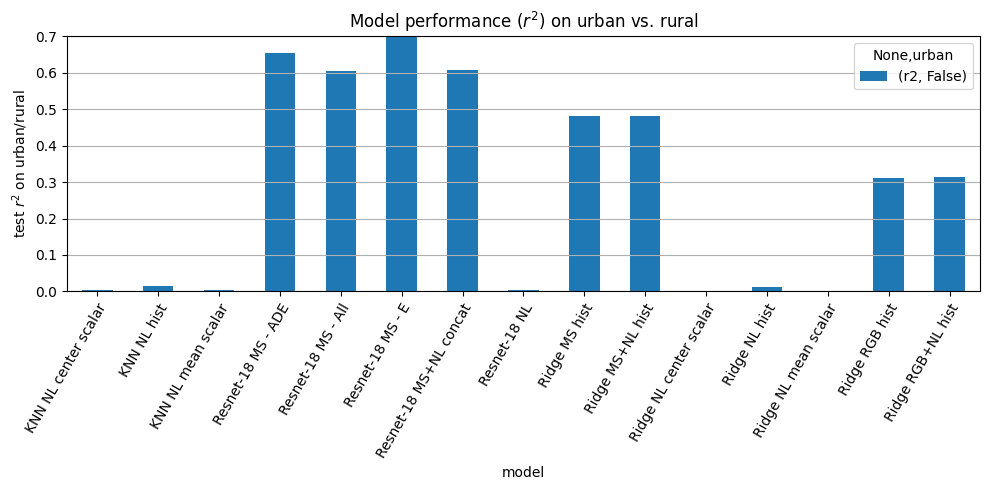

In [23]:
ax = urban_rural_df.loc[:, ('r2', slice(None))].plot(
    kind='bar', figsize=[10, 5])
ax.set_ylabel('test $r^2$ on urban/rural')
ax.set_ylim(bottom=0, top=0.7)
ax.set_title('Model performance ($r^2$) on urban vs. rural')
ax.grid(True, axis='y')
# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=60, ha='right',
         rotation_mode='anchor')
plt.tight_layout()
plt.show()

Histogram with model evaluation (R2 or coefficient of determination) split by Cluster Types

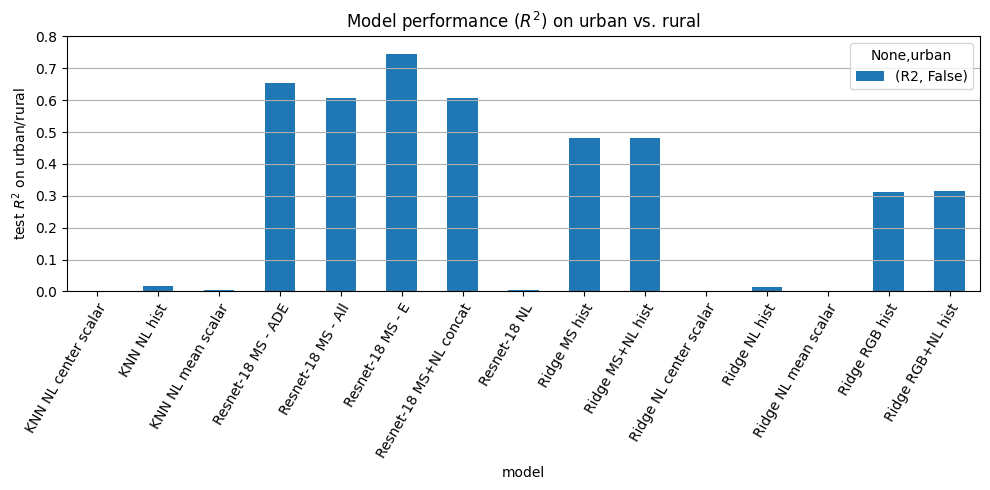

In [24]:
ax = urban_rural_df.loc[:, ('R2', slice(None))].plot(
    kind='bar', figsize=[10, 5])
ax.set_ylabel('test $R^2$ on urban/rural')
ax.set_ylim(bottom=0, top=0.8)
ax.set_title('Model performance ($R^2$) on urban vs. rural')
ax.grid(True, axis='y')
# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=60, ha='right',
         rotation_mode='anchor')
plt.tight_layout()
plt.show()

Plot Ridge Evaluations split by Cluster Type

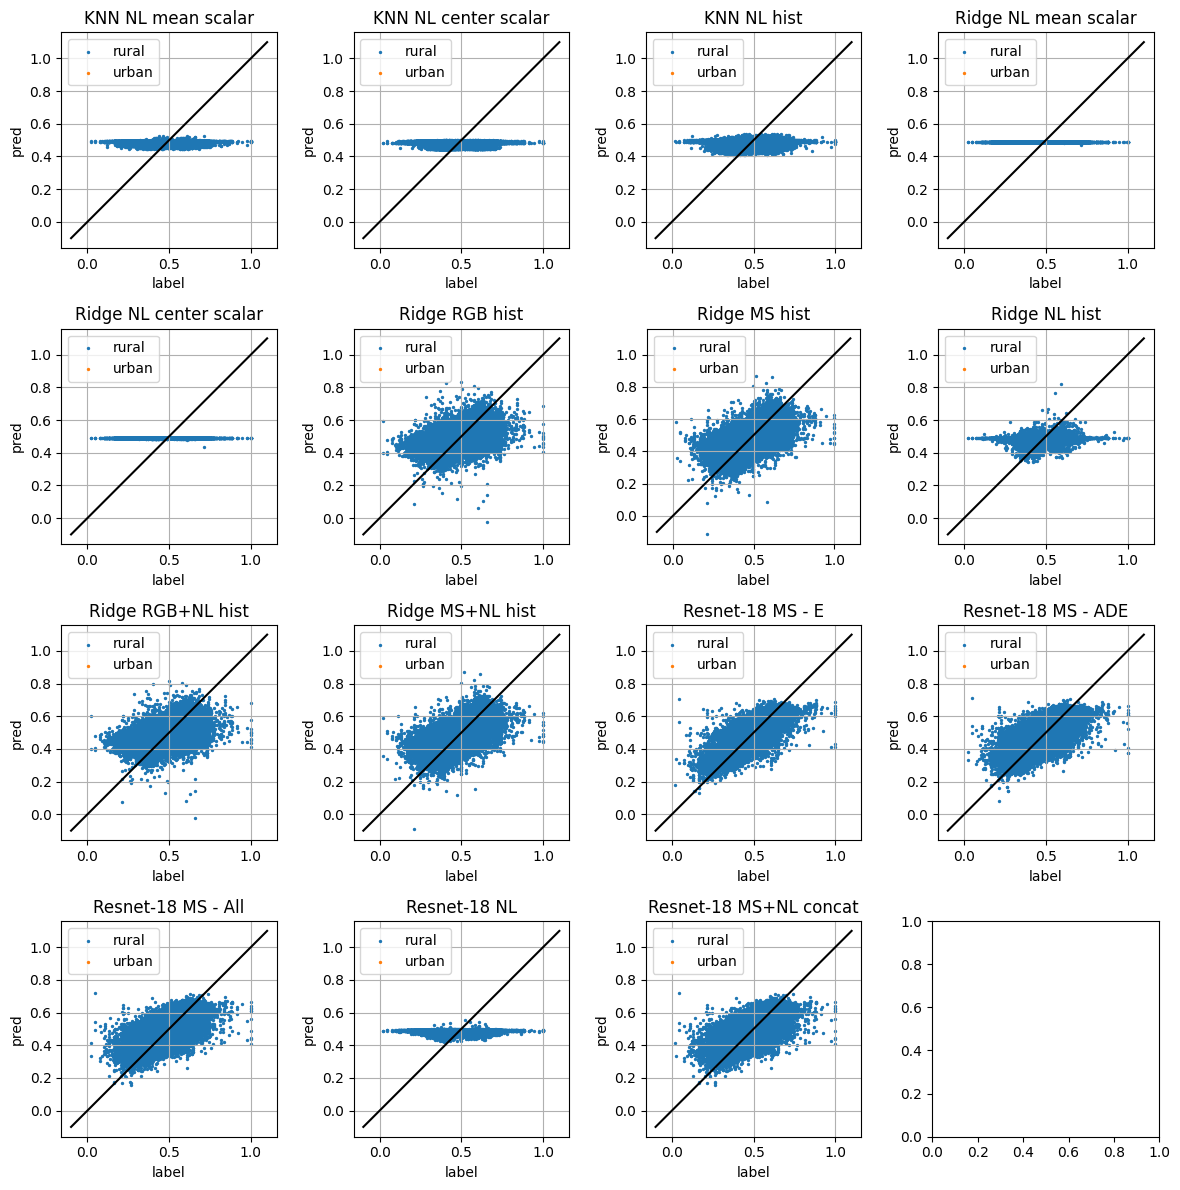

In [25]:
def plot_urban_rural_predictions(labels, preds, urban_indices, rural_indices):
    '''
    Args
    - labels: np.array, shape [N]
    - preds: dict, model_name => np.array, shape [N]
    - urban_indices: np.array, shape [num_urban]
    - rural_indices: np.array, shape [num_rural]
    '''
    nrows = int(np.ceil(np.sqrt(len(preds))))
    ncols = int(np.ceil(len(preds) / nrows))
    fig, axs = plt.subplots(nrows=nrows, ncols=ncols,
                            sharey=False, sharex=False, figsize=[ncols*3, nrows*3])
    for model_name, ax in zip(preds, axs.flat):
        ax.scatter(
            x=labels[rural_indices],
            y=preds[model_name][rural_indices],
            s=2, label='rural')
        ax.scatter(
            x=labels[urban_indices],
            y=preds[model_name][urban_indices],
            s=2, label='urban')
        ax.grid(True)
        ax.set_aspect('equal')
        ax.set(xlabel='label', ylabel='pred', title=model_name)
        xy_line = np.array([-0.1,1.1])
        ax.plot(xy_line, xy_line, color='black')
        ax.legend()
    fig.tight_layout()
    plt.show()

plot_urban_rural_predictions(labels, preds, urban_indices, rural_indices)

# Model performance as function of NL

## When NL = 0

In [26]:
from batchers.batcher import MEANS_DICT, STD_DEVS_DICT

dmsp0 = (0.0 - MEANS_DICT[DATASET_NAME]['DMSP']) / STD_DEVS_DICT[DATASET_NAME]['DMSP']


print('DMSP 0-value (after normalization):', dmsp0)


dmsp0_indices = (years < 2012) & (nls_mean == dmsp0)

nl0_indices = dmsp0_indices 

assert np.all(nls_mean[nl0_indices] == dmsp0)
assert np.all(nls_center[nl0_indices] == dmsp0)

2024-01-11 23:54:49.666907: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512F
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-01-11 23:54:49.810254: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:460] Initializing the SageMaker Profiler.
2024-01-11 23:54:49.810359: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:105] SageMaker Profiler is not enabled. The timeline writer thread will not be started, future recorded events will be dropped.
2024-01-11 23:54:49.837831: W tensorflow/core/profiler/internal/smprofiler_timeline.cc:460] Initializing the SageMaker Profiler.


DMSP 0-value (after normalization): -0.15828391418569285


In [27]:
print('# of locs w/ DMSP=0:', np.sum(dmsp0_indices))
print('# of locs w/ NL=0:', np.sum(nl0_indices))

# of locs w/ DMSP=0: 0
# of locs w/ NL=0: 0


Because we train a separate ridge regression model for each left-out test country, we get many different predictions for when NL = 0.

### Plot Ridge Evaluations split by Cluster Type

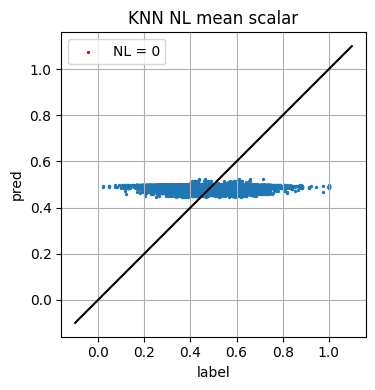

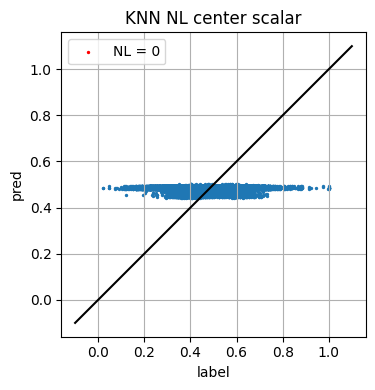

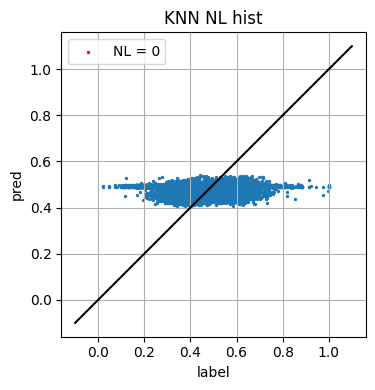

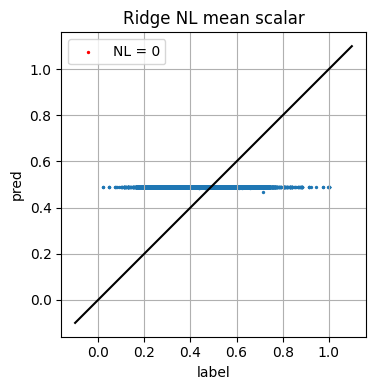

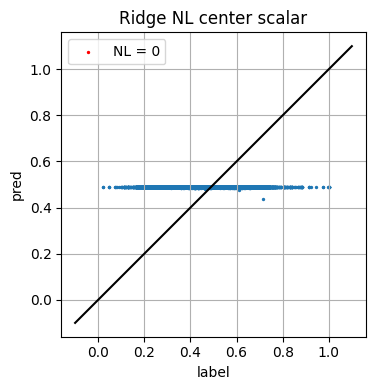

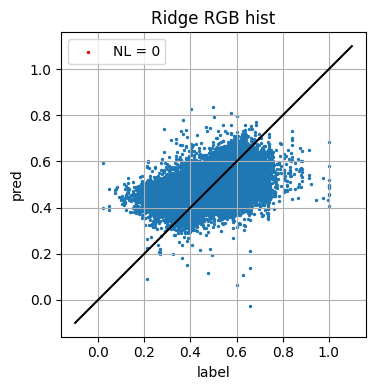

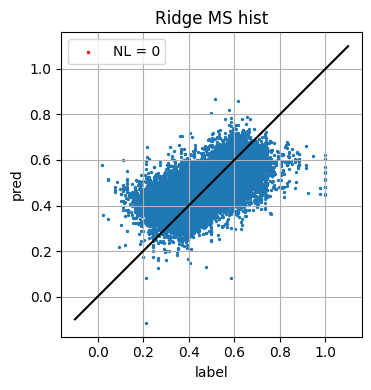

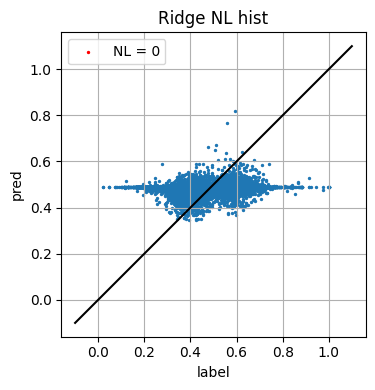

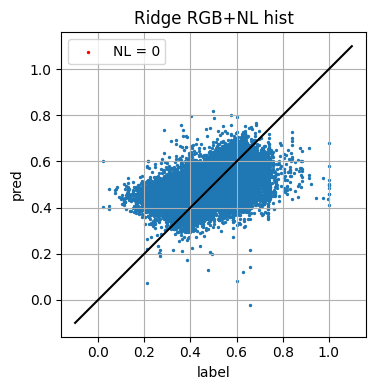

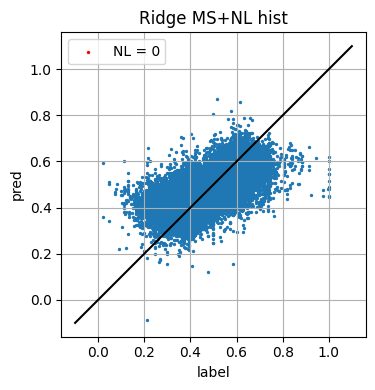

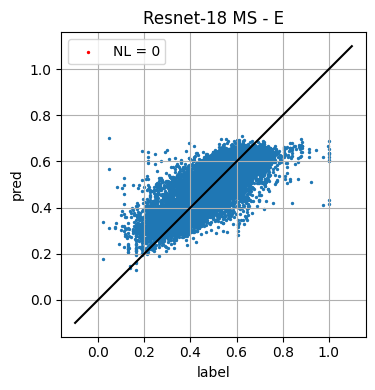

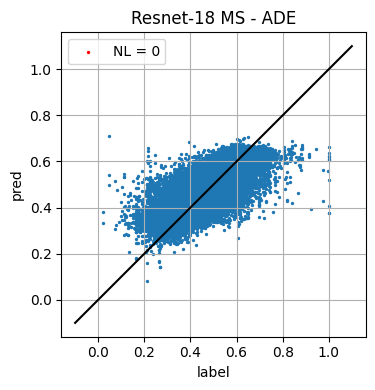

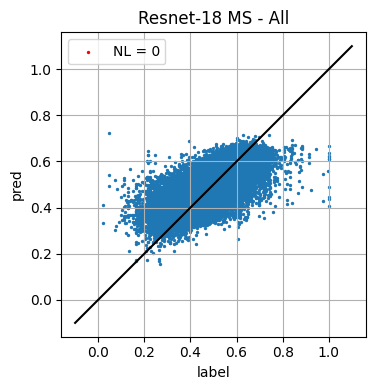

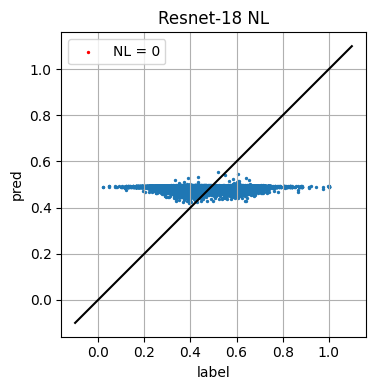

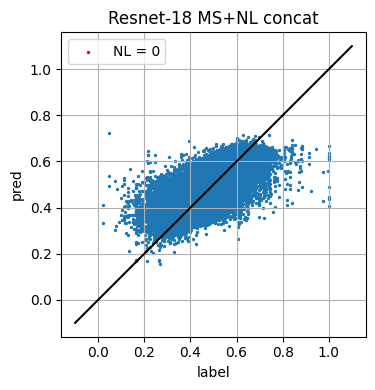

In [28]:
def plot_preds_nl0(model_name, labels, preds, nl0_indices):
    '''
    Args
    - model_name: str
    - labels: np.array, shape [num_examples]
    - preds: np.array, shape [num_examples]
    - nl0_indices: np.array, integer indices into labels/preds
    '''
    fig, ax = plt.subplots(1, 1, figsize=[4, 4])
    ax.scatter(x=labels, y=preds, s=2)
    ax.scatter(x=labels[nl0_indices], y=preds[nl0_indices], c='red', s=2, label='NL = 0')
    ax.set(xlabel='label', ylabel='pred', title=model_name)
    ax.grid(True)
    ax.set_aspect('equal')
    xy_line = np.array([-0.1, 1.1])
    ax.plot(xy_line, xy_line, color='black')
    ax.legend()
    fig.tight_layout()
    plt.show()

for model_name in MODEL_NAME_TO_DIR:
    plot_preds_nl0(model_name, labels, preds[model_name], nl0_indices)

### DataFrame with model evaluation split by Cluster Types

In [29]:
nl0_df = evaluate_df(preds_df.loc[nl0_indices, :], cols=MODEL_NAMES)
nl0_df.sort_values('r2', ascending=False, inplace=True)
nl0_df.to_csv('/root/reproducible/logs/income/performance_without_nl.csv')
with pd.option_context('display.max_rows', 20, 'display.precision', 5):
    display(nl0_df)

ValueError: x and y must have length at least 2.

## Target vs. NL mean

In [30]:
def plot_label_v_nl(label, preds, nl_means):
    '''
    Args
    - model_name: str
    - preds: np.array
    - nl_means: np.array
    '''
    fig, ax = plt.subplots(1, 1, figsize=[5, 5])
    ax.scatter(
            x=nl_means[rural_indices],
            y=preds[rural_indices],
            s=2, label='rural')
    ax.scatter(
            x=nl_means[urban_indices],
            y=preds[urban_indices],
            s=2, label='urban')
    
    ax.set_title(label)
    ax.set_xlabel('Mean NL of Image (std dev from mean)')
    ax.set_ylabel(f'{label} Indicator')
    ax.grid(True)
    fig.tight_layout()
    plt.legend(['rural','urban'])
    plt.show()

Plot the Target indicator in function of the Mean NL Value of the Image

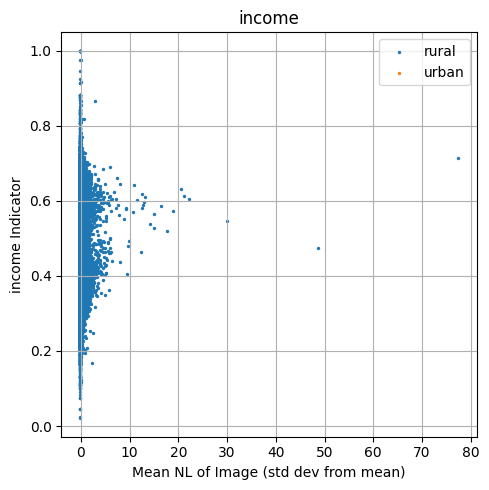

<Figure size 640x480 with 0 Axes>

In [31]:
plot_label_v_nl(label, labels, nls_mean)
plt.savefig("income_mean_NL")

## Predictions vs. NL mean

In [32]:
def plot_preds_v_nl(model_name, preds, nl_means):
    '''
    Args
    - model_name: str
    - preds: np.array
    - nl_means: np.array
    '''
    fig, ax = plt.subplots(1, 1, figsize=[5, 5])
    ax.scatter(
            x=nl_means[rural_indices],
            y=preds[rural_indices],
            s=2, label='rural')
    ax.scatter(
            x=nl_means[urban_indices],
            y=preds[urban_indices],
            s=2, label='urban')
    
    ax.set_title(model_name)
    ax.set_xlabel('Mean NL of Image (std dev from mean)')
    ax.set_ylabel('Predicted Income')
    ax.grid(True)
    fig.tight_layout()
    plt.legend(['rural','urban'])
    plt.show()

def plot_residuals_v_nl(model_name, preds, labels, nl_means):
    '''
    Args
    - model_name: str
    - preds: np.array
    - labels: np.array
    - nl_means: np.array
    '''
    residuals = labels - preds
    fig, ax = plt.subplots(1, 1, figsize=[5, 5])
    ax.scatter(x=nl_means, y=residuals, s=3)
    ax.set_title(model_name)
    ax.set_xlabel('Mean NL of Image (std dev from mean)')
    ax.set_ylabel('Residual (label - pred)')
    ax.grid(True)
    fig.tight_layout()
    plt.show()

For each model, plots the predicted indicator in function of the Mean NL Value of the Image

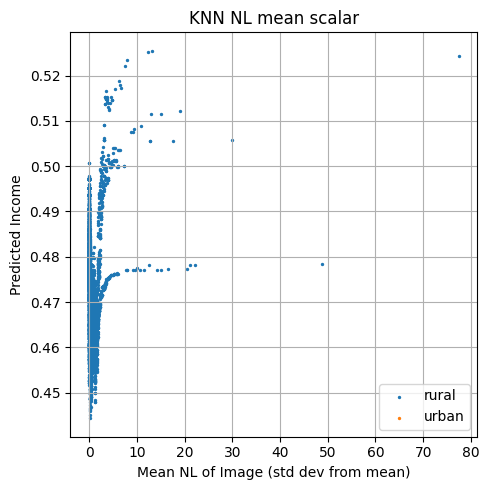

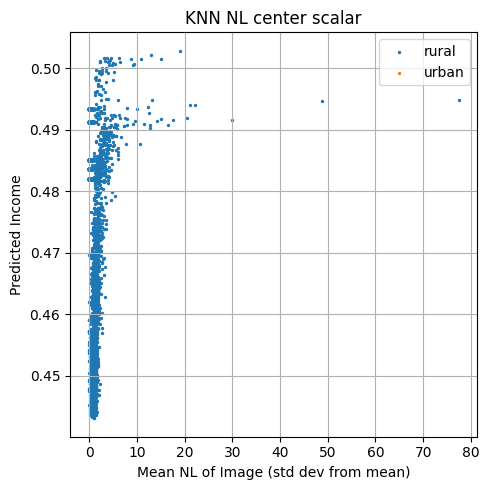

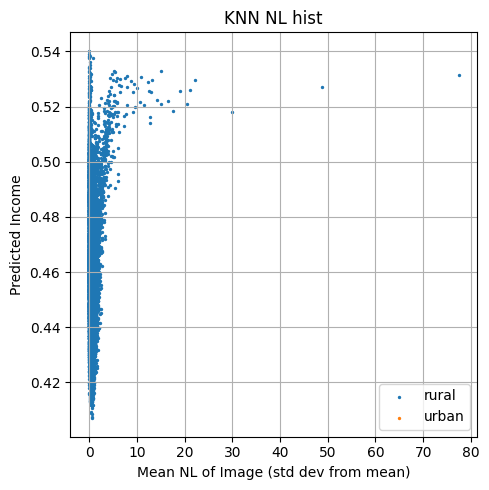

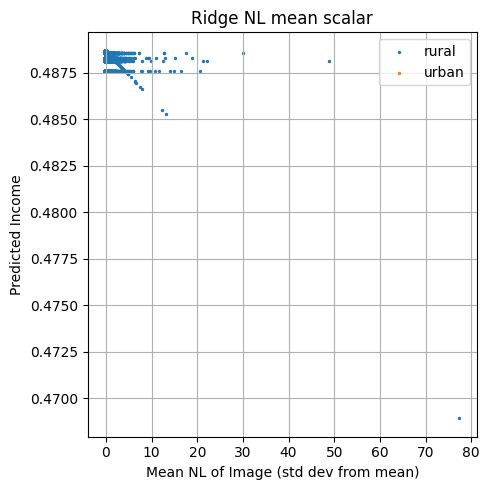

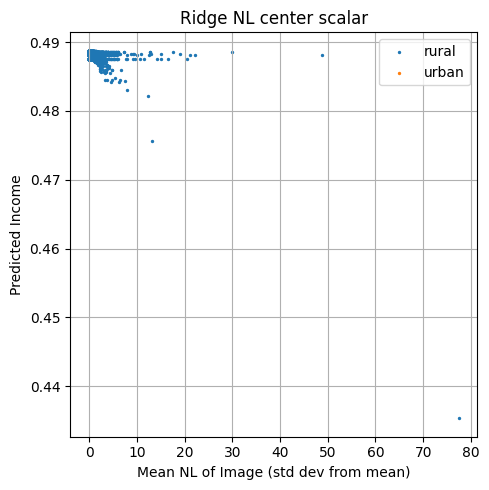

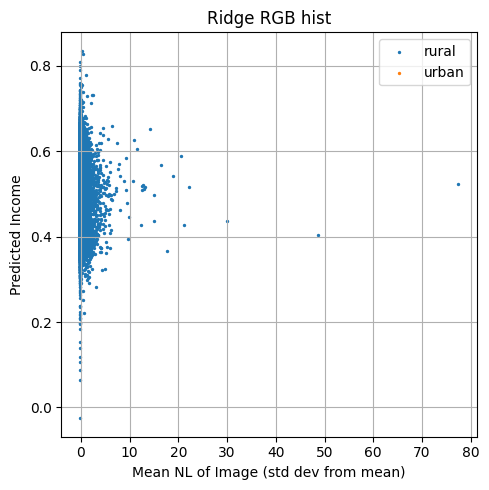

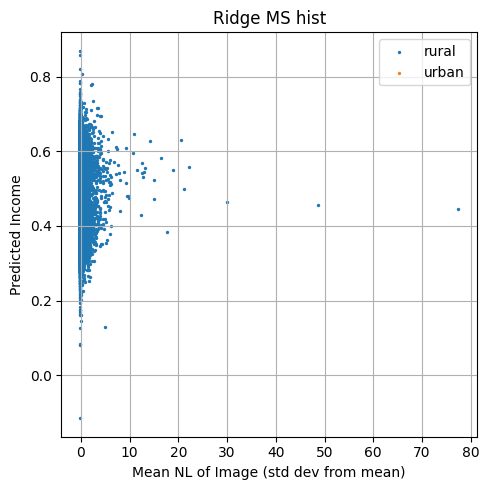

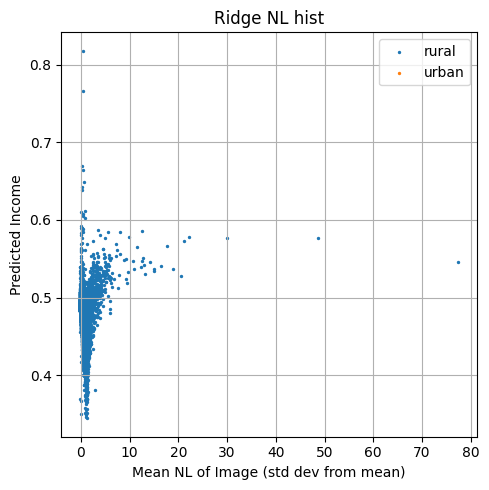

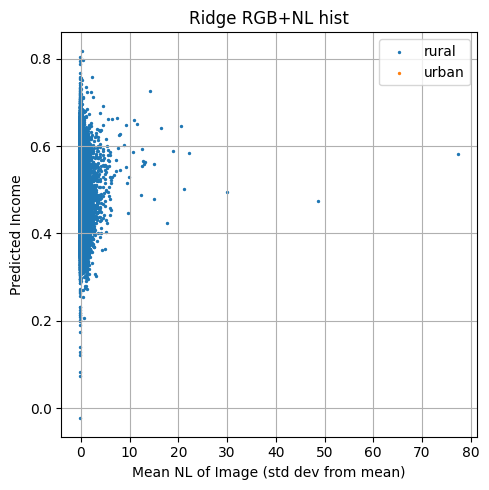

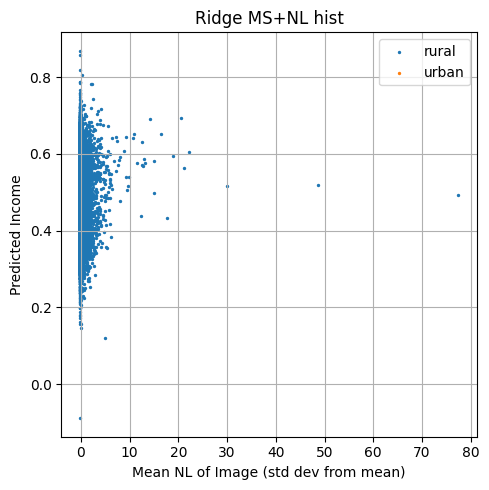

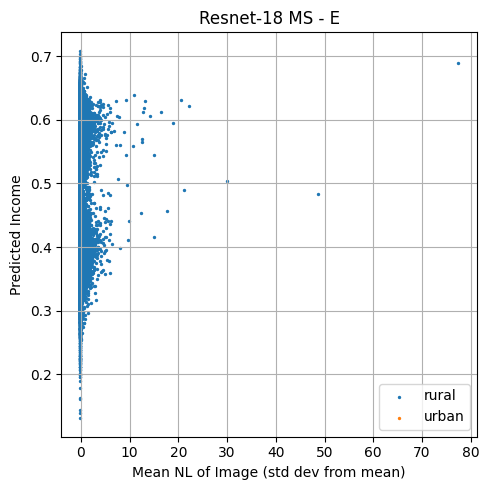

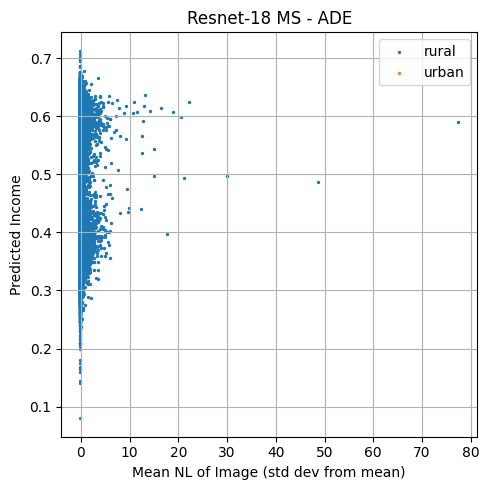

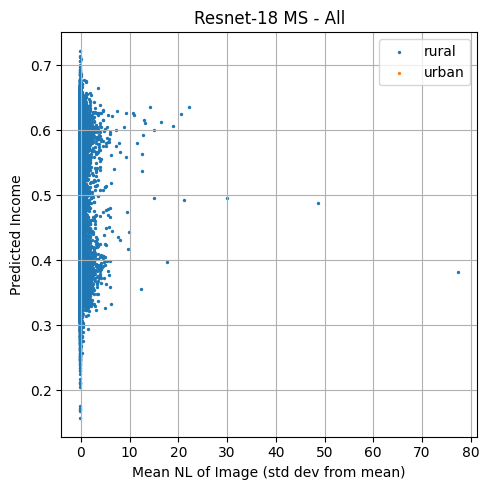

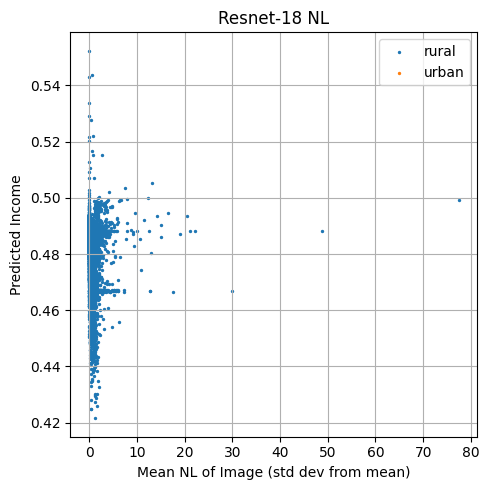

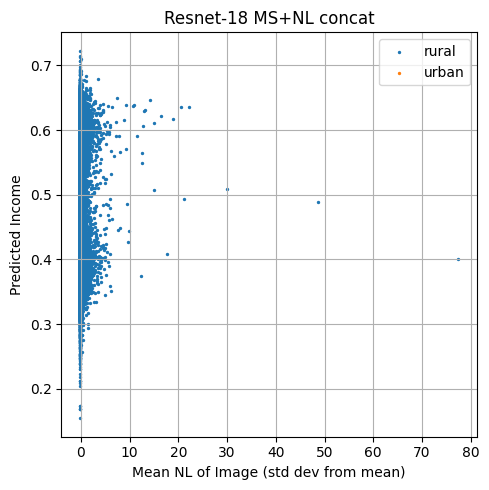

In [33]:
for model_name in MODEL_NAME_TO_DIR:
    plot_preds_v_nl(model_name, preds[model_name], nls_mean)